# Traffic Sign Classifier - Homework 12

In [88]:
import cv2
from time import time
import numpy as np
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Sequential

## Data Loading

Let's load classes 0 and 1.

In [89]:
classes = ["30 sign", "50 sign"]    

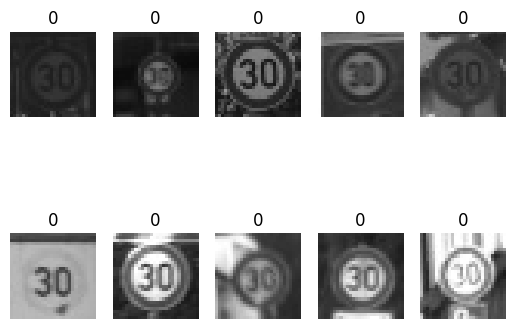

In [90]:
folder = Path("../data/subset_homework")
class_0_dir = folder / "class_id_0"

fnames_0 = class_0_dir.iterdir()
images_0 = [cv2.imread(filename, cv2.IMREAD_UNCHANGED) for filename in fnames_0]
labels_0 = [0] * len(images_0)

for cnt, idx in enumerate(np.random.randint(0, len(images_0), 10)):
    plt.subplot(2,5,cnt+1)
    plt.imshow(images_0[idx], cmap="gray", vmin=0, vmax=255)
    plt.title(labels_0[idx]), plt.axis(False)

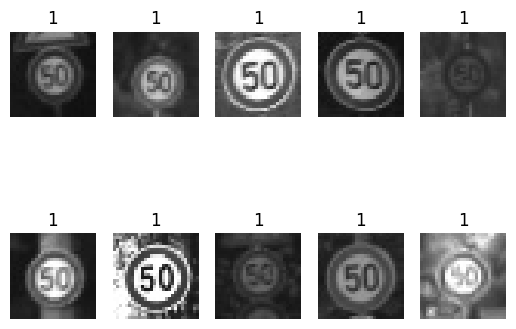

In [91]:
folder = Path("../data/subset_homework")
class_1_dir = folder / "class_id_1"

fnames_1 = class_1_dir.iterdir()
images_1 = [cv2.imread(filename, cv2.IMREAD_UNCHANGED) for filename in fnames_1]
labels_1 = [1] * len(images_1)

for cnt, idx in enumerate(np.random.randint(0, len(images_1), 10)):
    plt.subplot(2,5,cnt+1)
    plt.imshow(images_1[idx], cmap="gray", vmin=0, vmax=255)
    plt.title(labels_1[idx]), plt.axis(False)

In [92]:
print("Num samples class_0:", len(images_0))
print("Num samples class_1:", len(images_1))

Num samples class_0: 2220
Num samples class_1: 2250


## Data Preprocessing

Before feeding the data to neural network, we need to prepare a single dataset and flatted 2D images to a vector.

In [93]:
images = images_0 + images_1
labels = labels_0 + labels_1
images, labels = shuffle(images, labels)

images = np.array(images)
labels = np.array(labels)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

pixels = np.array([image.flatten() for image in images])/255
print("Pixels shape:", pixels.shape)

Images shape: (4470, 28, 28)
Labels shape: (4470,)
Pixels shape: (4470, 784)


Also let's split our dataset into train and test, so the comparison is fair.

In [94]:
X_train, X_test, y_train, y_test = train_test_split(
    pixels, labels, test_size=0.2, random_state=42, stratify=labels
)

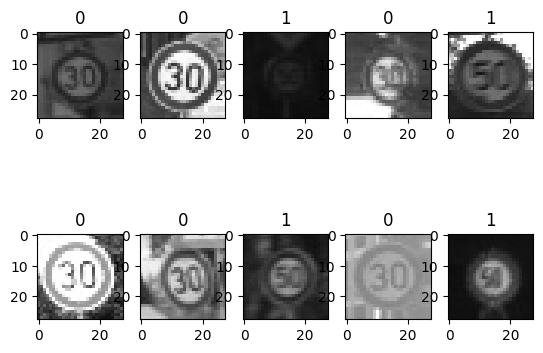

In [95]:
# printing a random sample from the dataset
for cnt, idx in enumerate(np.random.randint(0, len(images), 10)):    
    plt.subplot(2,5,cnt+1)
    plt.imshow(images[idx], cmap="gray", vmin=0, vmax=255)
    plt.title(labels[idx])

## Training the model

In [96]:
inputs = Input(shape=(pixels.shape[1], ))
outputs = Dense(1, activation="linear")(inputs)
model = Model(inputs, outputs)

model.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)          │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 1)                   │             785 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 785 (3.07 KB)

 Trainable params: 785 (3.07 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3446    
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2311 
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1857 
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1640 
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1450   
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1333   
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1202 
Epoch 8/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1153   
Epoch 9/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1047 
Epoch 10/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0997 


(Text(0.5, 0, 'epoch'), Text(0, 0.5, 'loss'))

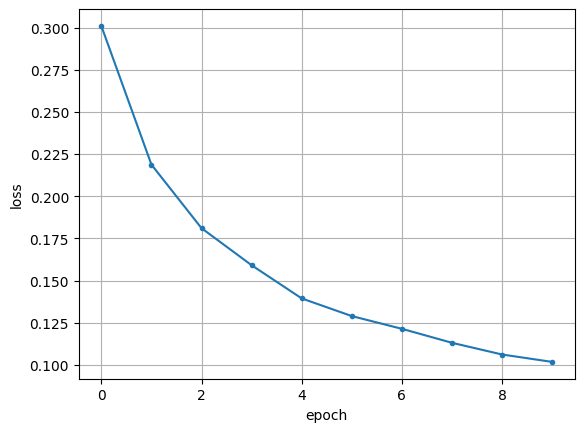

In [97]:
model.compile(optimizer ="adam", loss = "mse")
history = model.fit(X_train, y_train, epochs=10, batch_size=32)

h = history.history
epochs = range(len(h["loss"]))
plt.plot(epochs, h["loss"], ".-"), plt.grid(True)
plt.xlabel("epoch"), plt.ylabel("loss")

Trained weights:
[0.3736354] [0.3736354]


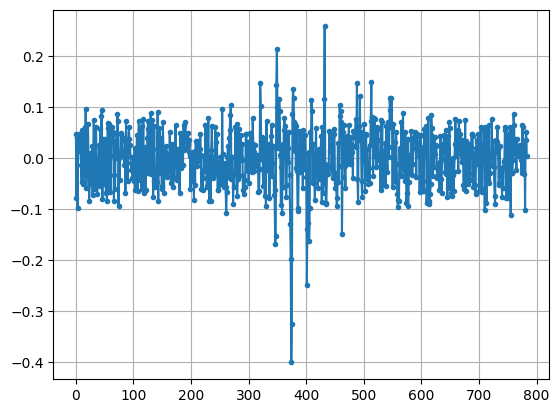

In [98]:
plt.plot(model.layers[1].weights[0].numpy(), ".-"), plt.grid(True)
print("Trained weights:")
print(model.layers[1].weights[1].numpy(), model.layers[1].bias.numpy())

## Testing and evaluating the model

In [99]:
def evaluate_model(model, X_test, y_test):
    preds = model.predict(X_test).squeeze()
    preds = (preds > 0.5).astype(int).ravel()

    correct = np.sum(preds == y_test)
    accuracy = correct / len(y_test)

    print(f"Accuracy: {accuracy:.4f}")
    return preds, accuracy

In [100]:
predictions, accuracy = evaluate_model(model, X_train, y_train)

112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step   
Accuracy: 0.9007


In [101]:
predictions, accuracy = evaluate_model(model, X_test, y_test)

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Accuracy: 0.8982


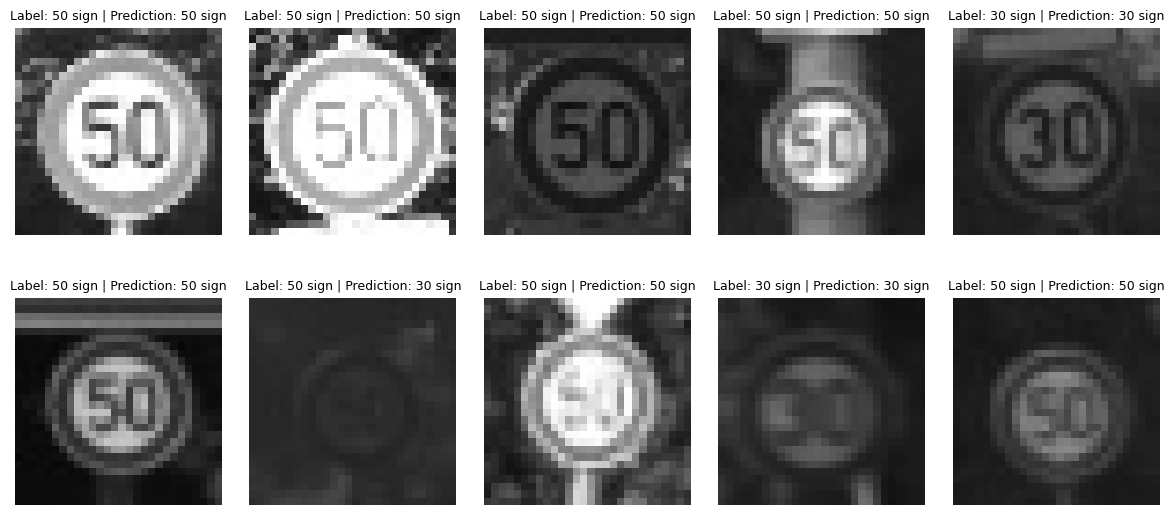

In [102]:
plt.figure(figsize=(12, 6))

for cnt, idx in enumerate(np.random.randint(0, len(X_test), 10)):
    plt.subplot(2, 5, cnt + 1)
    plt.imshow(X_test[idx].reshape(images.shape[1], images.shape[2]),
               cmap="gray", vmin=0, vmax=1)

    true_class = classes[y_test[idx]]
    predicted_class = classes[predictions[idx]]
    plt.title(f"Label: {true_class} | Prediction: {predicted_class}", fontsize=9)
    plt.axis("off")

plt.tight_layout(pad=2.0)
plt.show()

## Improving Accuracy

Currently with a simple network our accuracy is **0.9128** on the test dataset. Let's try to improve it by adding more layers and neurons (but still using only Dense layers).

In [103]:
model = Sequential([
    Input(shape=(pixels.shape[1], )),
    Dense(32, activation="relu"),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1, activation="linear")
])

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                     │ (None, 32)                  │          25,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.4961 
Epoch 2/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1958   
Epoch 3/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1487    
Epoch 4/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1074 
Epoch 5/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0931 
Epoch 6/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0810 
Epoch 7/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0843 
Epoch 8/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0692 
Epoch 9/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0606    
Epoch 10/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0591 
Epoch 11/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0505  
Epoch 12/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0574  
Epoch 13/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0370 
Epoch 14/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0452   
Epoch 15/15
112/112 ━━━━━━━━━━━

(Text(0.5, 0, 'epoch'), Text(0, 0.5, 'loss'))

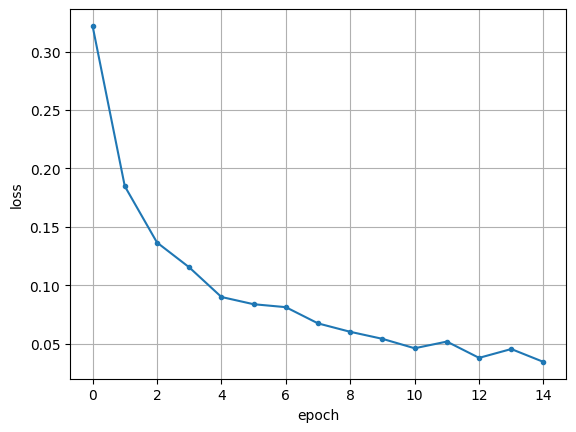

In [104]:
model.compile(optimizer="adam", loss="mse")
history = model.fit(X_train, y_train, epochs=15, batch_size=32)

h = history.history
epochs = range(len(h["loss"]))
plt.plot(epochs, h["loss"], ".-"), plt.grid(True)
plt.xlabel("epoch"), plt.ylabel("loss")

In [105]:
predictions, accuracy = evaluate_model(model, X_train, y_train)

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step   
Accuracy: 0.9695


In [106]:
predictions, accuracy = evaluate_model(model, X_test, y_test)

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Accuracy: 0.9575


So, we reached **0.9575 accuracy**, which is better than with the first model.